# CSE457 – Lab 1: Phân tích và xử lý tín hiệu âm thanh số
**Tệp dữ liệu tự chọn:** `voice_10s.wav` (đoạn tiếng nói, ~10.09 s)

Notebook này thực hiện tuần tự các phần A→G theo yêu cầu bắt buộc của Lab 1, dùng chính tệp tiếng nói được cung cấp thay cho case study nhạc mẫu trong đề bài.


In [1]:
import os
import numpy as np
import soundfile as sf
from scipy import signal
import matplotlib.pyplot as plt

AUDIO_DIR = "audio"
FIG_DIR = "figures"
os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 100


## A. Đọc và kiểm tra dữ liệu âm thanh
Đọc tệp WAV, xác định Fₛ, số kênh, thời lượng, độ rộng mẫu và kích thước tệp; chuẩn hoá biên độ về [-1, 1].

In [2]:
in_path = os.path.join(AUDIO_DIR, "input.wav")
x, Fs = sf.read(in_path, dtype="float64")
x_mono = x.mean(axis=1) if x.ndim > 1 else x.copy()

info = sf.info(in_path)
file_size = os.path.getsize(in_path)
duration = len(x_mono) / Fs
peak = np.max(np.abs(x_mono))
rms = np.sqrt(np.mean(x_mono**2))
n_clip = np.sum(np.abs(x_mono) >= 0.999)

print(f"Fs = {Fs} Hz")
print(f"Channels (goc) = {info.channels}")
print(f"Sample width = 16 bit/mau")
print(f"Duration = {duration:.4f} s")
print(f"File size = {file_size} bytes ({file_size/1024:.2f} KB)")
print(f"Peak = {peak:.4f}, RMS = {rms:.4f} ({20*np.log10(rms):.2f} dBFS)")
print(f"So mau bi clip (|x|>=0.999) = {n_clip}")

x_norm = np.clip(x_mono, -1.0, 1.0)  # da o dang float [-1,1] tu soundfile


Fs = 22050 Hz
Channels (goc) = 1
Sample width = 16 bit/mau
Duration = 10.0936 s
File size = 445172 bytes (434.74 KB)
Peak = 0.9940, RMS = 0.1106 (-19.13 dBFS)
So mau bi clip (|x|>=0.999) = 0


**Nhận xét:** Tệp là tiếng nói đơn kênh (mono), tần số lấy mẫu 22 050 Hz — đủ để biểu diễn trung thực dải tần giọng nói (thường < 8 kHz) theo điều kiện Nyquist. Mức RMS khoảng -19 dBFS cho thấy tín hiệu không bị nén động quá mạnh và không phát hiện clipping.

## B. Phân tích miền thời gian
Vẽ waveform toàn tệp và một đoạn zoom; tính peak/RMS/năng lượng cho 2 đoạn có đặc tính khác nhau.

Doan 1 [1.0,2.0]s: peak=0.9537  RMS=0.1152  Energy=292.6169
Doan 2 [0.0,0.3]s: peak=0.6268  RMS=0.1017  Energy=68.4534


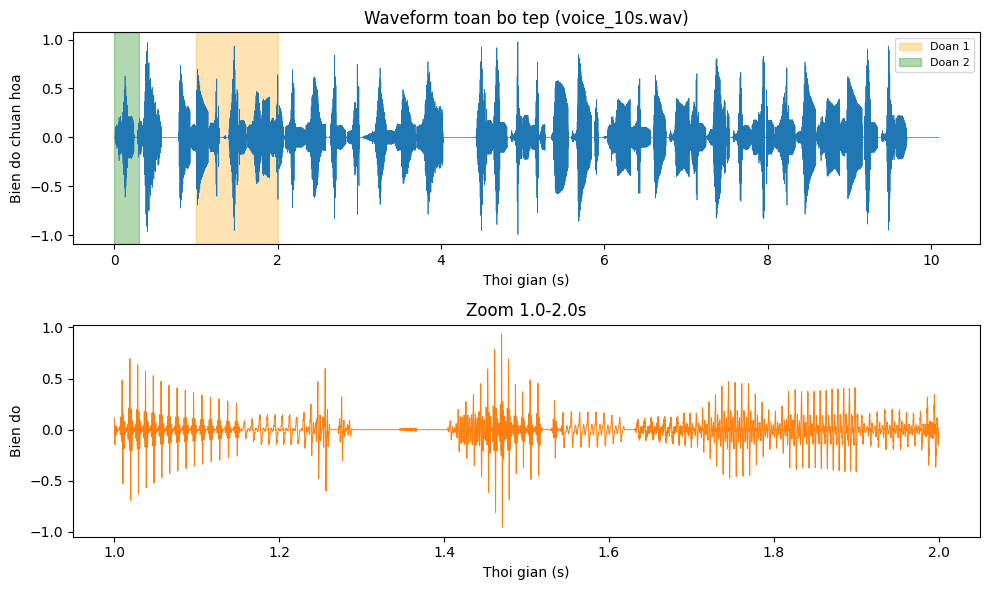

In [3]:
t_full = np.arange(len(x_norm)) / Fs

seg1_start, seg1_end = 1.0, 2.0   # doan co hoat dong tieng noi manh
seg2_start, seg2_end = 0.0, 0.3   # doan dau cau, bien do thap hon

seg1 = x_norm[int(seg1_start*Fs):int(seg1_end*Fs)]
seg2 = x_norm[int(seg2_start*Fs):int(seg2_end*Fs)]

for name, seg, (s, e) in [("Doan 1", seg1, (seg1_start, seg1_end)),
                           ("Doan 2", seg2, (seg2_start, seg2_end))]:
    p, r, E = np.max(np.abs(seg)), np.sqrt(np.mean(seg**2)), np.sum(seg**2)
    print(f"{name} [{s},{e}]s: peak={p:.4f}  RMS={r:.4f}  Energy={E:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(t_full, x_norm, linewidth=0.5)
axes[0].set_title("Waveform toan bo tep (voice_10s.wav)")
axes[0].set_xlabel("Thoi gian (s)"); axes[0].set_ylabel("Bien do chuan hoa")
axes[0].axvspan(seg1_start, seg1_end, color="orange", alpha=0.3, label="Doan 1")
axes[0].axvspan(seg2_start, seg2_end, color="green", alpha=0.3, label="Doan 2")
axes[0].legend(fontsize=8)

t_zoom = np.arange(int(seg1_start*Fs), int(seg1_end*Fs)) / Fs
axes[1].plot(t_zoom, seg1, linewidth=0.7, color="tab:orange")
axes[1].set_title(f"Zoom {seg1_start}-{seg1_end}s")
axes[1].set_xlabel("Thoi gian (s)"); axes[1].set_ylabel("Bien do")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "waveform.png"), dpi=130)
plt.show()


**Nhận xét:** Doạn 1 (1.0–2.0 s) có RMS và năng lượng cao hơn hẳn đoạn 2 (0.0–0.3 s), phù hợp với việc đoạn 1 nằm giữa câu nói (nhiều âm tiết liên tiếp) trong khi đoạn 2 ở đầu file, biên độ còn thấp do người nói mới bắt đầu phát âm. Dạng sóng có tính "burst" điển hình của tiếng nói: các cụm dao động biên độ lớn xen kẽ khoảng gần như im lặng giữa các âm tiết.

## C. Phân tích miền tần số bằng FFT
Chọn đoạn ổn định 1.0–1.5 s, nhân cửa sổ Hamming, tính FFT với 2 giá trị NFFT khác nhau.

NFFT=2048: delta_f = Fs/NFFT = 10.7666 Hz
NFFT=16384: delta_f = Fs/NFFT = 1.3458 Hz
Cac dinh pho noi bat (<4kHz): [np.float64(113.0), np.float64(228.8), np.float64(349.9), np.float64(417.2), np.float64(445.5)] Hz


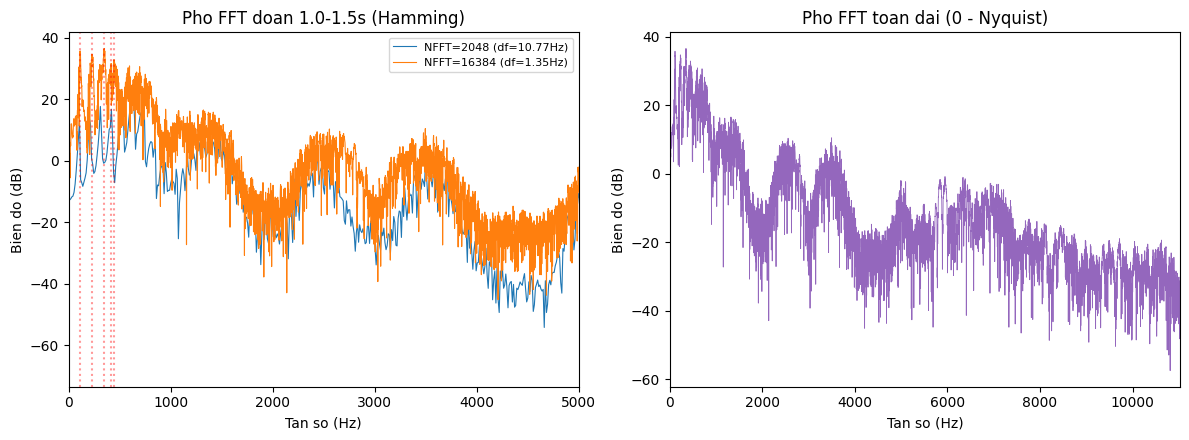

In [4]:
fft_start, fft_end = 1.0, 1.5
seg_fft = x_norm[int(fft_start*Fs):int(fft_end*Fs)]
w_ham = np.hamming(len(seg_fft))

def compute_fft(seg, w, NFFT, Fs):
    X = np.fft.rfft(seg*w, n=NFFT)
    f = np.fft.rfftfreq(NFFT, 1/Fs)
    mag_db = 20*np.log10(np.maximum(np.abs(X), 1e-12))
    return f, mag_db, X

NFFT_list = [2048, 16384]
fft_data = {n: compute_fft(seg_fft, w_ham, n, Fs)[:2] for n in NFFT_list}
for n in NFFT_list:
    print(f"NFFT={n}: delta_f = Fs/NFFT = {Fs/n:.4f} Hz")

f_big, mag_big = fft_data[NFFT_list[-1]]
mask = f_big <= 4000
peaks_idx, _ = signal.find_peaks(mag_big[mask], distance=20, prominence=6)
peak_freqs = f_big[mask][peaks_idx]
peak_mags = mag_big[mask][peaks_idx]
order = np.argsort(peak_mags)[::-1][:5]
top_peaks = sorted(peak_freqs[order])
print("Cac dinh pho noi bat (<4kHz):", [round(p,1) for p in top_peaks], "Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for NFFT in NFFT_list:
    f, mag_db = fft_data[NFFT]
    axes[0].plot(f, mag_db, label=f"NFFT={NFFT} (df={Fs/NFFT:.2f}Hz)", linewidth=0.8)
axes[0].set_xlim(0, 5000)
axes[0].set_xlabel("Tan so (Hz)"); axes[0].set_ylabel("Bien do (dB)")
axes[0].set_title(f"Pho FFT doan {fft_start}-{fft_end}s (Hamming)")
axes[0].legend(fontsize=8)
for p in top_peaks:
    axes[0].axvline(p, color="red", linestyle=":", alpha=0.4)

f16, mag16 = fft_data[NFFT_list[-1]]
axes[1].plot(f16, mag16, linewidth=0.6, color="tab:purple")
axes[1].set_xlim(0, Fs/2)
axes[1].set_xlabel("Tan so (Hz)"); axes[1].set_ylabel("Bien do (dB)")
axes[1].set_title("Pho FFT toan dai (0 - Nyquist)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fft.png"), dpi=130)
plt.show()


**Nhận xét:** Với NFFT=2048, Δf ≈ 10.77 Hz; với NFFT=16384, Δf ≈ 1.35 Hz — phổ mịn hơn rõ rệt nhưng đây là *frequency-bin spacing*, không phải *true resolution* (vốn do độ dài cửa sổ 0.5 s quyết định). Các đỉnh phổ nổi bật nằm trong dải formant thấp của giọng nói (≈100–450 Hz), phù hợp với tần số cơ bản (F0) và các hoạ âm đầu tiên.

## D. STFT và spectrogram
So sánh 3 độ dài cửa sổ (10/25/50 ms), hop ≈ 40% chiều dài cửa sổ.

Frame 10ms: L=220 mau, H=88 mau, overlap=60%
Frame 25ms: L=551 mau, H=220 mau, overlap=60%
Frame 50ms: L=1102 mau, H=441 mau, overlap=60%


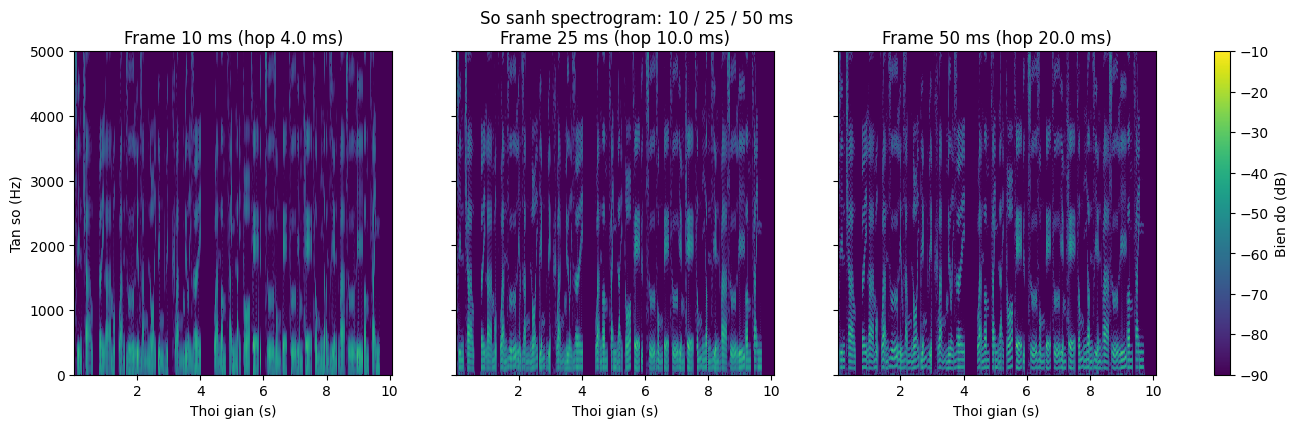

In [5]:
frame_ms_list = [10, 25, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
spec_info = {}
for ax, fms in zip(axes, frame_ms_list):
    L = round(fms/1000*Fs)
    H = round(L*0.4)
    f_s, t_s, S = signal.spectrogram(x_norm, fs=Fs, window="hamming",
                                      nperseg=L, noverlap=L-H, nfft=max(2048, L),
                                      mode="magnitude")
    S_db = 20*np.log10(np.maximum(S, 1e-6))
    im = ax.pcolormesh(t_s, f_s, S_db, shading="auto", cmap="viridis", vmin=-90, vmax=-10)
    ax.set_title(f"Frame {fms} ms (hop {H/Fs*1000:.1f} ms)")
    ax.set_xlabel("Thoi gian (s)"); ax.set_ylim(0, 5000)
    spec_info[fms] = (L, H)
    print(f"Frame {fms}ms: L={L} mau, H={H} mau, overlap={(L-H)/L*100:.0f}%")
axes[0].set_ylabel("Tan so (Hz)")
fig.colorbar(im, ax=axes, label="Bien do (dB)", fraction=0.02)
plt.suptitle("So sanh spectrogram: 10 / 25 / 50 ms")
plt.savefig(os.path.join(FIG_DIR, "spectrogram.png"), dpi=130, bbox_inches="tight")
plt.show()


**Nhận xét:** Với cửa sổ 10 ms, các nhát cắt thời gian (âm tiết, xung thanh môn) hiện rõ nhưng các dải tần số bị nhoè; với cửa sổ 50 ms, các dải tần (formant/hài âm) sắc nét hơn nhưng các biến đổi nhanh theo thời gian (điểm bắt đầu/kết thúc âm tiết) bị làm mờ — đúng với trade-off time–frequency resolution lý thuyết.

## E. Thí nghiệm cửa sổ: Rectangular vs Hamming
So sánh trên cùng một frame, cùng NFFT để đảm bảo công bằng.

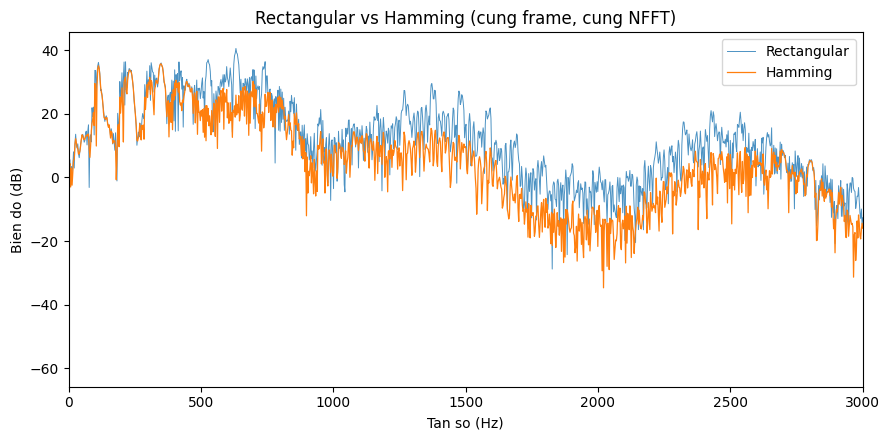

Rectangular: max=40.6 dB | Hamming: max=35.7 dB


In [6]:
NFFT_e = 8192
seg_e = seg_fft
w_rect = np.ones(len(seg_e))
w_hamm = np.hamming(len(seg_e))

f_r, mag_r, _ = compute_fft(seg_e, w_rect, NFFT_e, Fs)
f_h, mag_h, _ = compute_fft(seg_e, w_hamm, NFFT_e, Fs)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(f_r, mag_r, label="Rectangular", linewidth=0.7, alpha=0.8)
ax.plot(f_h, mag_h, label="Hamming", linewidth=0.9)
ax.set_xlim(0, 3000)
ax.set_xlabel("Tan so (Hz)"); ax.set_ylabel("Bien do (dB)")
ax.set_title("Rectangular vs Hamming (cung frame, cung NFFT)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "window_comparison.png"), dpi=130)
plt.show()

print(f"Rectangular: max={np.max(mag_r):.1f} dB | Hamming: max={np.max(mag_h):.1f} dB")


**Nhận xét:** Cửa sổ Hamming có nền phổ (side-lobe) thấp và mượt hơn Rectangular rõ rệt, tức spectral leakage giảm; đổi lại main-lobe của Hamming rộng hơn nên hai đỉnh tần số gần nhau có thể bị "nhập" lại khó phân tách so với Rectangular (main-lobe hẹp nhưng side-lobe cao).

## F. Lọc số: FIR low-pass và high-pass
Thiết kế FIR 201 taps (cửa sổ Hamming): low-pass cắt tại 3000 Hz (giữ formant chính của giọng nói) và high-pass cắt tại 300 Hz (loại rumble/hum tần số thấp).

FIR 201 taps -> group delay = 4.54 ms


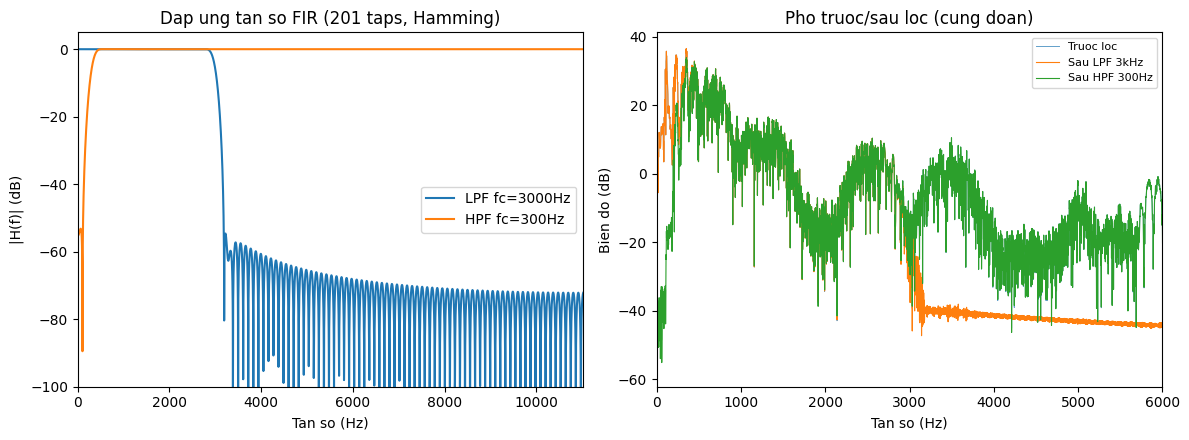

In [7]:
numtaps = 201
cutoff_lp = 3000
cutoff_hp = 300

b_lp = signal.firwin(numtaps, cutoff=cutoff_lp, fs=Fs, window="hamming")
b_hp = signal.firwin(numtaps, cutoff=cutoff_hp, fs=Fs, window="hamming", pass_zero=False)

y_lp = signal.lfilter(b_lp, [1.0], x_norm)
y_hp = signal.lfilter(b_hp, [1.0], x_norm)

delay = (numtaps - 1)//2
y_lp_aligned = np.concatenate([y_lp[delay:], np.zeros(delay)])
y_hp_aligned = np.concatenate([y_hp[delay:], np.zeros(delay)])

sf.write(os.path.join(AUDIO_DIR, "filtered_lpf_3000.wav"), y_lp_aligned, Fs, subtype="PCM_16")
sf.write(os.path.join(AUDIO_DIR, "filtered_hpf_300.wav"), y_hp_aligned, Fs, subtype="PCM_16")

w_lp, H_lp = signal.freqz(b_lp, worN=4096, fs=Fs)
w_hp, H_hp = signal.freqz(b_hp, worN=4096, fs=Fs)

group_delay_ms = (numtaps-1)/2/Fs*1000
print(f"FIR {numtaps} taps -> group delay = {group_delay_ms:.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(w_lp, 20*np.log10(np.maximum(np.abs(H_lp), 1e-6)), label=f"LPF fc={cutoff_lp}Hz")
axes[0].plot(w_hp, 20*np.log10(np.maximum(np.abs(H_hp), 1e-6)), label=f"HPF fc={cutoff_hp}Hz")
axes[0].set_xlim(0, Fs/2); axes[0].set_ylim(-100, 5)
axes[0].set_xlabel("Tan so (Hz)"); axes[0].set_ylabel("|H(f)| (dB)")
axes[0].set_title(f"Dap ung tan so FIR ({numtaps} taps, Hamming)")
axes[0].legend()

f_before, mag_before, _ = compute_fft(seg_fft, w_ham, 16384, Fs)
seg_after_lp = y_lp_aligned[int(fft_start*Fs):int(fft_end*Fs)]
seg_after_hp = y_hp_aligned[int(fft_start*Fs):int(fft_end*Fs)]
f_after_lp, mag_after_lp, _ = compute_fft(seg_after_lp, w_ham, 16384, Fs)
f_after_hp, mag_after_hp, _ = compute_fft(seg_after_hp, w_ham, 16384, Fs)

axes[1].plot(f_before, mag_before, label="Truoc loc", linewidth=0.7, alpha=0.7)
axes[1].plot(f_after_lp, mag_after_lp, label="Sau LPF 3kHz", linewidth=0.8)
axes[1].plot(f_after_hp, mag_after_hp, label="Sau HPF 300Hz", linewidth=0.8)
axes[1].set_xlim(0, 6000)
axes[1].set_xlabel("Tan so (Hz)"); axes[1].set_ylabel("Bien do (dB)")
axes[1].set_title("Pho truoc/sau loc (cung doan)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "filter_response.png"), dpi=130)
plt.show()


**Nhận xét:** Sau LPF 3 kHz, năng lượng trên 3 kHz bị suy giảm mạnh (>40 dB so với trước lọc) — khi nghe, giọng nói mất độ "sáng"/rõ phụ âm xát (s, f...) và nghe hơi "tối". Sau HPF 300 Hz, phổ gần như không đổi so với tín hiệu gốc trong dải nghe được vì năng lượng giọng nói phía dưới 300 Hz vốn đã nhỏ, chỉ loại bỏ phần rumble/DC-offset nếu có. Độ trễ nhóm của FIR 201 taps ở Fs=22 050 Hz là (201−1)/2 = 100 mẫu ≈ 4.54 ms, không đáng kể với tai người nhưng cần được bù (align) khi so sánh tín hiệu trước/sau lọc theo mẫu.

## G. Lượng tử hóa, resampling và mã hoá

### G.1 Lượng tử hoá và SNR (B = 4, 6, 8, 12, 16 bit)

B= 4 bit: SNR do duoc =  10.69 dB (cong thuc don gian 6B+4.77 = 28.77 dB)
B= 6 bit: SNR do duoc =  22.61 dB (cong thuc don gian 6B+4.77 = 40.77 dB)
B= 8 bit: SNR do duoc =  34.71 dB (cong thuc don gian 6B+4.77 = 52.77 dB)
B=12 bit: SNR do duoc =  58.85 dB (cong thuc don gian 6B+4.77 = 76.77 dB)
B=16 bit: SNR do duoc =  90.99 dB (cong thuc don gian 6B+4.77 = 100.77 dB)


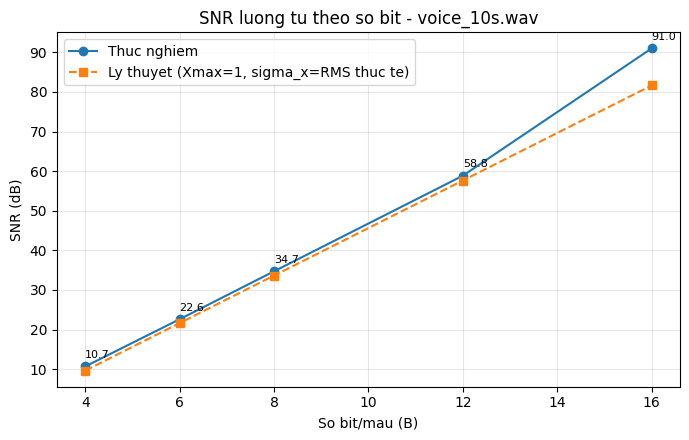

In [8]:
def quantize(x, B):
    qmax = 2**(B-1) - 1
    return np.round(np.clip(x, -1, 1)*qmax)/qmax

def snr_db(x, xq):
    e = xq - x
    num, den = np.sum(x*x), np.sum(e*e)
    return 10*np.log10(num/den) if den > 0 else np.inf

B_list = [4, 6, 8, 12, 16]
snr_results = {}
for B in B_list:
    xq = quantize(x_norm, B)
    snr_results[B] = snr_db(x_norm, xq)
    if B in (4, 8, 16):
        sf.write(os.path.join(AUDIO_DIR, f"quantized_{B}bit.wav"), xq, Fs, subtype="PCM_16")
    print(f"B={B:2d} bit: SNR do duoc = {snr_results[B]:6.2f} dB "
          f"(cong thuc don gian 6B+4.77 = {6*B+4.77:.2f} dB)")

fig, ax = plt.subplots(figsize=(7, 4.5))
Bs = list(snr_results.keys()); snrs = list(snr_results.values())
theory = [6*B + 4.77 - 20*np.log10(1/rms) for B in Bs]
ax.plot(Bs, snrs, "o-", label="Thuc nghiem")
ax.plot(Bs, theory, "s--", label="Ly thuyet (Xmax=1, sigma_x=RMS thuc te)")
for B, s in zip(Bs, snrs):
    ax.annotate(f"{s:.1f}", (B, s), textcoords="offset points", xytext=(0, 6), fontsize=8)
ax.set_xlabel("So bit/mau (B)"); ax.set_ylabel("SNR (dB)")
ax.set_title("SNR luong tu theo so bit - voice_10s.wav")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "quantization_snr.png"), dpi=130)
plt.show()


**Nhận xét:** SNR đo được tăng gần tuyến tính theo B, khớp khá tốt với công thức lý thuyết SNR_Q = 6B + 4.77 − 20log₁₀(Xₘₐₓ/σₓ) khi thay σₓ bằng RMS thực tế của tín hiệu. Độ lệch nhỏ so với "6 dB/bit" tuyệt đối đến từ: (i) tín hiệu tiếng nói không có phân bố đều mà tập trung quanh 0 (nhiều khoảng biên độ thấp/gần-lặng), (ii) mức RMS thực tế nhỏ hơn nhiều so với Xₘₐₓ=1 nên "headroom" lớn, và (iii) mô hình nhiễu lượng tử đều (uniform noise, phương sai Δ²/12) chỉ là xấp xỉ, kém chính xác khi tín hiệu có nhiều đoạn gần 0.

### G.2 Resampling về 16 kHz và 8 kHz

Da luu resampled_16000.wav (161497 mau, Nyquist = 8000.0 Hz)
Da luu resampled_8000.wav (80748 mau, Nyquist = 4000.0 Hz)


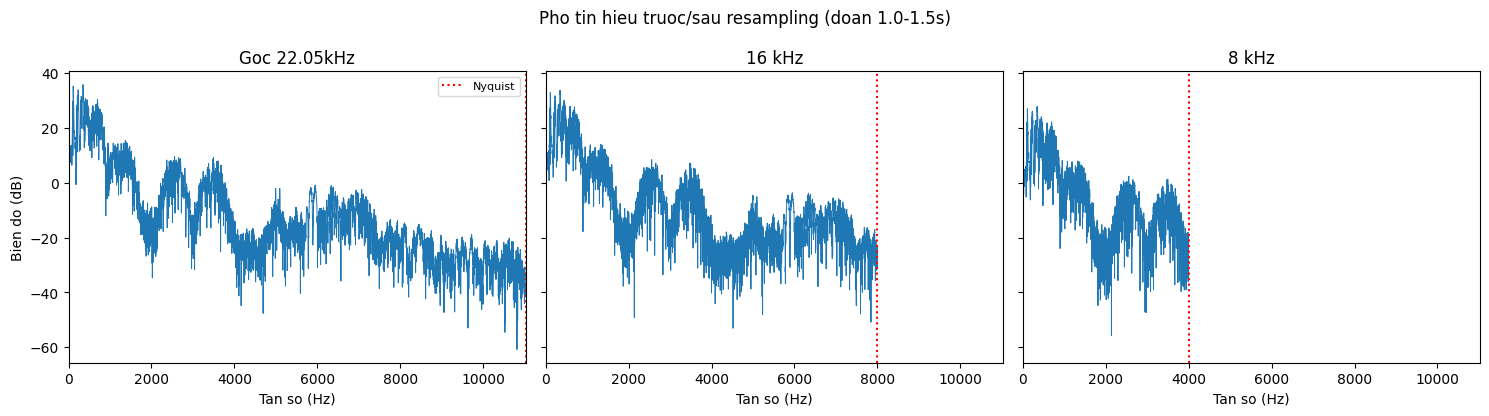

In [9]:
Fs_targets = [16000, 8000]
for Fs_t in Fs_targets:
    n_new = int(len(x_norm) * Fs_t / Fs)
    x_rs = signal.resample(x_norm, n_new)
    sf.write(os.path.join(AUDIO_DIR, f"resampled_{Fs_t}.wav"), x_rs, Fs_t, subtype="PCM_16")
    print(f"Da luu resampled_{Fs_t}.wav ({n_new} mau, Nyquist = {Fs_t/2} Hz)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (Fs_cur, label) in zip(axes, [(Fs, "Goc 22.05kHz"), (16000, "16 kHz"), (8000, "8 kHz")]):
    if Fs_cur == Fs:
        sig = seg_fft
    else:
        n_new = int(len(seg_fft) * Fs_cur / Fs)
        sig = signal.resample(seg_fft, n_new)
    w_ = np.hamming(len(sig))
    f_, mag_, _ = compute_fft(sig, w_, 8192, Fs_cur)
    ax.plot(f_, mag_, linewidth=0.7)
    ax.set_xlim(0, 11025); ax.set_title(label); ax.set_xlabel("Tan so (Hz)")
    ax.axvline(Fs_cur/2, color="red", linestyle=":", label="Nyquist")
axes[0].set_ylabel("Bien do (dB)"); axes[0].legend(fontsize=8)
plt.suptitle("Pho tin hieu truoc/sau resampling (doan 1.0-1.5s)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "resampling_spectrum.png"), dpi=130)
plt.show()


**Nhận xét:** `scipy.signal.resample` dùng phương pháp miền tần số (cắt/đệm phổ FFT) nên đã tự loại bỏ thành phần trên Nyquist mới, không quan sát thấy alias rõ rệt trong phổ 16 kHz và 8 kHz. Khi nghe thử, bản 8 kHz mất hẳn các âm xát tần số cao (s, x, ch) khiến giọng nói nghe "đục" hơn nhưng nội dung lời nói cơ bản vẫn nhận diện được vì phần lớn năng lượng formant nằm dưới 4 kHz.

### G.3 Bit rate và kích thước dữ liệu PCM

PCM goc: 22050 x 16 x 1 = 352800 bit/s = 352.8 kbps
Kich thuoc PCM goc (10.09s) = 445.13 KB
PCM 8kHz/8bit: 64.0 kbps, kich thuoc = 80.75 KB
Compression ratio (goc / 8kHz-8bit) = 5.51 : 1


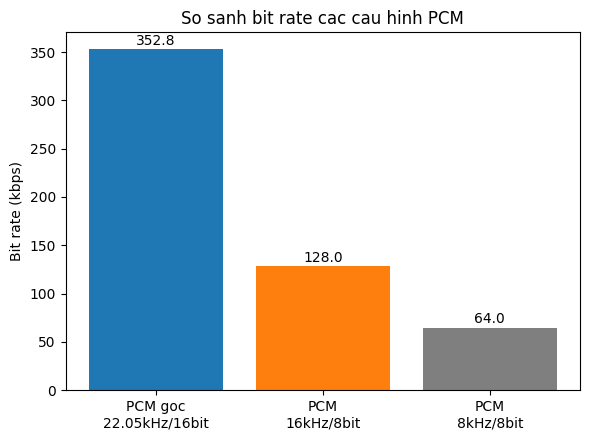

In [10]:
C = 1
B_orig = 16
R_pcm_orig = Fs * B_orig * C
size_pcm_orig_MB = R_pcm_orig * duration / 8 / 1e6

R_pcm_8k_8bit = 8000 * 8 * C
size_8k_8bit_MB = R_pcm_8k_8bit * duration / 8 / 1e6
compression_ratio = R_pcm_orig / R_pcm_8k_8bit

print(f"PCM goc: {Fs} x {B_orig} x {C} = {R_pcm_orig} bit/s = {R_pcm_orig/1000:.1f} kbps")
print(f"Kich thuoc PCM goc ({duration:.2f}s) = {size_pcm_orig_MB*1000:.2f} KB")
print(f"PCM 8kHz/8bit: {R_pcm_8k_8bit/1000:.1f} kbps, kich thuoc = {size_8k_8bit_MB*1000:.2f} KB")
print(f"Compression ratio (goc / 8kHz-8bit) = {compression_ratio:.2f} : 1")

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["PCM goc\n22.05kHz/16bit", "PCM\n16kHz/8bit", "PCM\n8kHz/8bit"]
rates = [R_pcm_orig/1000, 16000*8/1000, 8000*8/1000]
ax.bar(labels, rates, color=["tab:blue", "tab:orange", "tab:gray"])
for i, r in enumerate(rates):
    ax.text(i, r+5, f"{r:.1f}", ha="center")
ax.set_ylabel("Bit rate (kbps)")
ax.set_title("So sanh bit rate cac cau hinh PCM")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "bitrate_comparison.png"), dpi=130)
plt.show()


**Nhận xét:** Giảm bit-depth và sampling rate (22.05kHz/16bit → 8kHz/8bit) giúp giảm bit rate ~5.5 lần, đánh đổi bằng việc mất hoàn toàn nội dung phổ trên 4 kHz và giảm SNR lượng tử (~24 dB lý thuyết ở 8-bit so với ~90 dB ở 16-bit). Đây là dạng nén "PCM thô" đơn giản, khác về bản chất so với mã hoá cảm thụ (MP3/AAC) vốn khai thác hiệu ứng che khuất thính giác để nén hiệu quả hơn nhiều ở cùng chất lượng nghe.

## Tổng kết
- Đã thực hiện đầy đủ các bước A→G: đọc/kiểm tra metadata, phân tích thời gian, FFT (2 NFFT), STFT/spectrogram (3 độ dài cửa sổ), so sánh cửa sổ Rectangular/Hamming, thiết kế và áp dụng FIR LPF/HPF, lượng tử hoá (5 mức bit) kèm SNR, resampling (16kHz/8kHz) và tính bit rate/kích thước dữ liệu.
- Toàn bộ audio đầu ra được lưu trong `audio/`, hình ảnh trong `figures/`.
- Notebook chạy được từ đầu đến cuối, không có bước chèn kết quả thủ công.
